In [3]:
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import tifffile as tiff
from PIL import Image

import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from skimage.transform import resize
from skimage.measure import label as sk_label

from cellpose import models

In [6]:
PROJECT_ROOT = Path(r"C:\Users\wangy\Downloads\cnn")
TEST_DIR = PROJECT_ROOT / "Testing"

TRAIN_OUT_DIR = PROJECT_ROOT / "outputs" / "train_cnn_pipeline"
MODEL_BUNDLE_PATH = TRAIN_OUT_DIR / "model" / "cnn.pt"

OUT_DIR = PROJECT_ROOT / "outputs" / "infer_compare"
PRED_MASK_DIR = OUT_DIR / "predicted_masks"
DEFAULT_MASK_DIR = OUT_DIR / "default_masks"
COMPARE_DIR = OUT_DIR / "comparisons"

for d in [OUT_DIR, PRED_MASK_DIR, DEFAULT_MASK_DIR, COMPARE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

IMAGE_EXTS = {".png", ".bmp", ".tif", ".tiff", ".jpg", ".jpeg"}

USE_GPU = True
DEVICE = torch.device("cuda" if USE_GPU and torch.cuda.is_available() else "cpu")

MODEL_TYPE_FALLBACK = "cyto3"
CHANNELS_FALLBACK = [0, 0]

print("DEVICE:", DEVICE)
print("TEST_DIR exists:", TEST_DIR.exists())
print("MODEL_BUNDLE exists:", MODEL_BUNDLE_PATH.exists())

DEVICE: cuda
TEST_DIR exists: True
MODEL_BUNDLE exists: True


In [12]:
def list_images(folder):
    folder = Path(folder)
    return sorted([p for p in folder.iterdir() if p.is_file() and p.suffix.lower() in IMAGE_EXTS])

def read_image_any(path):
    path = Path(path)
    ext = path.suffix.lower()
    if ext in {".tif", ".tiff"}:
        arr = tiff.imread(str(path))
    else:
        arr = np.array(Image.open(path))

    arr = np.asarray(arr)
    if arr.ndim == 3:
        if arr.shape[-1] in (3, 4):
            arr = arr[..., :3].mean(axis=-1)
        else:
            arr = arr[0]

    arr = np.asarray(arr, dtype=np.float32)
    return arr

def normalize_image(img):
    img = np.asarray(img, dtype=np.float32)
    lo = np.percentile(img, 1)
    hi = np.percentile(img, 99)
    if hi <= lo:
        hi = img.max() if img.max() > lo else lo + 1.0
    img = (img - lo) / (hi - lo)
    img = np.clip(img, 0, 1)
    return img.astype(np.float32)

def resize_image_for_cnn(img, out_size):
    img = normalize_image(img)
    if img.shape != (out_size, out_size):
        img = resize(
            img,
            (out_size, out_size),
            preserve_range=True,
            anti_aliasing=True
        ).astype(np.float32)
    return img

def overlay_boundaries(image, mask):
    image = normalize_image(image)
    rgb = np.stack([image, image, image], axis=-1)

    mask_b = mask > 0
    edges = np.zeros_like(mask_b, dtype=bool)
    edges[:-1, :] |= (mask_b[:-1, :] != mask_b[1:, :])
    edges[1:,  :] |= (mask_b[:-1, :] != mask_b[1:, :])
    edges[:, :-1] |= (mask_b[:, :-1] != mask_b[:, 1:])
    edges[:, 1:]  |= (mask_b[:, :-1] != mask_b[:, 1:])

    rgb[edges, 0] = 1.0
    rgb[edges, 1] = 0.0
    rgb[edges, 2] = 0.0
    return rgb

In [15]:
class ParamComboCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

In [19]:
payload = torch.load(MODEL_BUNDLE_PATH, map_location=DEVICE, weights_only=False)

combo_table = pd.DataFrame(payload["combo_table"])
IMG_SIZE = int(payload["img_size"])
MODEL_TYPE = payload.get("model_type", MODEL_TYPE_FALLBACK)
CHANNELS = payload.get("channels", CHANNELS_FALLBACK)

model = ParamComboCNN(num_classes=len(combo_table))
model.load_state_dict(payload["state_dict"])
model = model.to(DEVICE)
model.eval()

print("IMG_SIZE:", IMG_SIZE)
print("MODEL_TYPE:", MODEL_TYPE)
print("CHANNELS:", CHANNELS)
display(combo_table.head())

IMG_SIZE: 128
MODEL_TYPE: cyto3
CHANNELS: [0, 0]


,combo_id,diameter,cellprob_threshold,flow_threshold
0,0,15.0,-2.0,0.2
1,1,15.0,-2.0,0.4
2,2,15.0,-2.0,0.6
3,3,15.0,0.0,0.2
4,4,15.0,0.0,0.4


In [16]:

def get_cellpose_model(use_gpu=True):
    return models.CellposeModel(gpu=use_gpu)

cp_model = get_cellpose_model(DEVICE.type == "cuda")

In [17]:
def predict_combo(model, combo_table_df, image_path, img_size, device):
    img = read_image_any(image_path)
    x = resize_image_for_cnn(img, img_size)
    x = torch.tensor(x[None, None, :, :], dtype=torch.float32).to(device)

    with torch.no_grad():
        logits = model(x)
        pred_class = int(logits.argmax(dim=1).item())

    combo = combo_table_df.loc[combo_table_df["combo_id"] == pred_class].iloc[0].to_dict()
    return pred_class, combo

In [10]:
test_images = list_images(TEST_DIR)
print("num test images:", len(test_images))

num test images: 13


In [12]:
summary_rows = []

for i, img_path in enumerate(test_images):
    key = img_path.stem
    print(f"[{i+1}/{len(test_images)}] {img_path.name}")

    img = read_image_any(img_path)

    pred_class, combo = predict_combo(model, combo_table, img_path, IMG_SIZE, DEVICE)

    pred_masks, _, _ = cp_model.eval(
        img,
        channels=CHANNELS,
        diameter=float(combo["diameter"]),
        cellprob_threshold=float(combo["cellprob_threshold"]),
        flow_threshold=float(combo["flow_threshold"]),
    )
    pred_masks = np.asarray(pred_masks)

    default_masks, _, _ = cp_model.eval(
        img,
        channels=CHANNELS,
    )
    default_masks = np.asarray(default_masks)

    pred_mask_path = PRED_MASK_DIR / f"{key}_predicted_mask.tif"
    default_mask_path = DEFAULT_MASK_DIR / f"{key}_default_mask.tif"

    tiff.imwrite(str(pred_mask_path), pred_masks.astype(np.int32))
    tiff.imwrite(str(default_mask_path), default_masks.astype(np.int32))

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes[0].imshow(normalize_image(img), cmap="gray")
    axes[0].set_title("image")

    axes[1].imshow(overlay_boundaries(img, pred_masks))
    axes[1].set_title(
        f"CNN predicted\nD={combo['diameter']}, CP={combo['cellprob_threshold']}, F={combo['flow_threshold']}"
    )

    axes[2].imshow(overlay_boundaries(img, default_masks))
    axes[2].set_title("Cellpose default")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    compare_path = COMPARE_DIR / f"{key}_comparison.png"
    plt.savefig(compare_path, dpi=180, bbox_inches="tight")
    plt.close()

    summary_rows.append({
        "image_name": img_path.name,
        "image_path": str(img_path),
        "pred_combo_id": pred_class,
        "pred_diameter": float(combo["diameter"]),
        "pred_cellprob_threshold": float(combo["cellprob_threshold"]),
        "pred_flow_threshold": float(combo["flow_threshold"]),
        "pred_mask_path": str(pred_mask_path),
        "default_mask_path": str(default_mask_path),
        "comparison_figure_path": str(compare_path),
        "pred_num_objects": int(pred_masks.max()) if pred_masks.size else 0,
        "default_num_objects": int(default_masks.max()) if default_masks.size else 0,
        "pred_foreground_pixels": int((pred_masks > 0).sum()),
        "default_foreground_pixels": int((default_masks > 0).sum()),
    })

channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used


[1/13] F04_118w1.TIF


channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used


[2/13] F04_118w2.TIF


channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used


...

channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
<tifffile.TiffFile 'TestHidden_279.tif'> OME series cannot handle discontiguous storage ((1920, 2560, 3) != (3, 1920, 2560))
<tifffile.TiffFile 'TestHidden_279.tif'> OME series cannot handle discontiguous storage ((1920, 2560, 3) != (3, 1920, 2560))


[12/13] TestHidden_279.tif


channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used


[13/13] TestHidden_357.bmp


channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used


In [13]:
summary_df = pd.DataFrame(summary_rows)
summary_csv = OUT_DIR / "prediction_vs_default_summary.csv"
summary_df.to_csv(summary_csv, index=False)

print("saved:", summary_csv)
display(summary_df.head())

saved: C:\Users\wangy\Downloads\cnn\outputs\infer_compare\prediction_vs_default_summary.csv


,image_name,image_path,pred_combo_id,pred_diameter,pred_cellprob_threshold,pred_flow_threshold,pred_mask_path,default_mask_path,comparison_figure_path,pred_num_objects,default_num_objects,pred_foreground_pixels,default_foreground_pixels
0,F04_118w1.TIF,C:\Users\wangy\Downloads\cnn\Testing\F04_118w1...,41,35.0,0.0,0.6,C:\Users\wangy\Downloads\cnn\outputs\infer_com...,C:\Users\wangy\Downloads\cnn\outputs\infer_com...,C:\Users\wangy\Downloads\cnn\outputs\infer_com...,48,39,270206,263569
1,F04_118w2.TIF,C:\Users\wangy\Downloads\cnn\Testing\F04_118w2...,41,35.0,0.0,0.6,C:\Users\wangy\Downloads\cnn\outputs\infer_com...,C:\Users\wangy\Downloads\cnn\outputs\infer_com...,C:\Users\wangy\Downloads\cnn\outputs\infer_com...,45,45,76484,80814
2,F04_159w1.TIF,C:\Users\wangy\Downloads\cnn\Testing\F04_159w1...,41,35.0,0.0,0.6,C:\Users\wangy\Downloads\cnn\outputs\infer_com...,C:\Users\wangy\Downloads\cnn\outputs\infer_com...,C:\Users\wangy\Downloads\cnn\outputs\infer_com...,33,33,215540,207302
3,F04_159w2.TIF,C:\Users\wangy\Downloads\cnn\Testing\F04_159w2...,41,35.0,0.0,0.6,C:\Users\wangy\Downloads\cnn\outputs\infer_com...,C:\Users\wangy\Downloads\cnn\outputs\infer_com...,C:\Users\wangy\Downloads\cnn\outputs\infer_com...,35,35,51158,51867
4,F04_29w1.TIF,C:\Users\wangy\Downloads\cnn\Testing\F04_29w1.TIF,41,35.0,0.0,0.6,C:\Users\wangy\Downloads\cnn\outputs\infer_com...,C:\Users\wangy\Downloads\cnn\outputs\infer_com...,C:\Users\wangy\Downloads\cnn\outputs\infer_com...,39,38,271513,266539


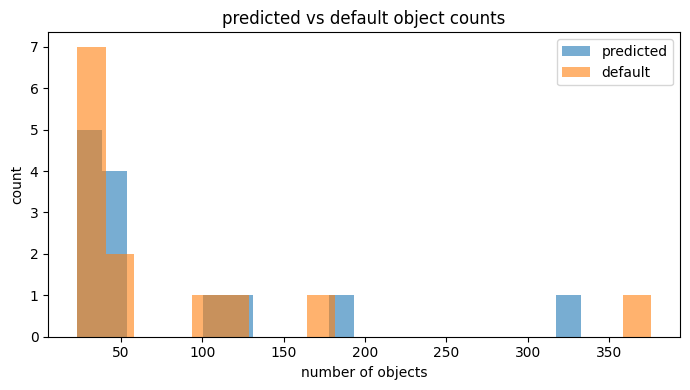

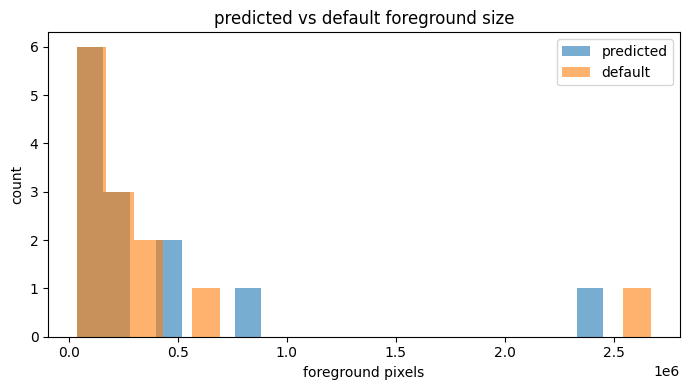

In [14]:
if len(summary_df) > 0:
    plt.figure(figsize=(7, 4))
    plt.hist(summary_df["pred_num_objects"], bins=20, alpha=0.6, label="predicted")
    plt.hist(summary_df["default_num_objects"], bins=20, alpha=0.6, label="default")
    plt.xlabel("number of objects")
    plt.ylabel("count")
    plt.title("predicted vs default object counts")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.hist(summary_df["pred_foreground_pixels"], bins=20, alpha=0.6, label="predicted")
    plt.hist(summary_df["default_foreground_pixels"], bins=20, alpha=0.6, label="default")
    plt.xlabel("foreground pixels")
    plt.ylabel("count")
    plt.title("predicted vs default foreground size")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [15]:
OVERLAY_DIR = OUT_DIR / "overlay_comparisons"
OVERLAY_DIR.mkdir(parents=True, exist_ok=True)

In [23]:
def make_mask_overlay(image, mask, boundary_only=True):
    image = normalize_image(image)
    rgb = np.stack([image, image, image], axis=-1)

    mask_bin = mask > 0

    if boundary_only:
        edges = np.zeros_like(mask_bin, dtype=bool)
        edges[:-1, :] |= (mask_bin[:-1, :] != mask_bin[1:, :])
        edges[1:,  :] |= (mask_bin[:-1, :] != mask_bin[1:, :])
        edges[:, :-1] |= (mask_bin[:, :-1] != mask_bin[:, 1:])
        edges[:, 1:]  |= (mask_bin[:, :-1] != mask_bin[:, 1:])

        rgb[edges, 0] = 1.0
        rgb[edges, 1] = 0.0
        rgb[edges, 2] = 0.0
    else:
        rgb[..., 0] = np.where(mask_bin, 1.0, rgb[..., 0])
        rgb[..., 1] = np.where(mask_bin, 0.3, rgb[..., 1])
        rgb[..., 2] = np.where(mask_bin, 0.3, rgb[..., 2])

    return rgb

In [25]:
N_SHOW = 17

for img_path in test_images[:N_SHOW]:
    img = read_image_any(img_path)

    pred_class, combo = predict_combo(model, combo_table, img_path, IMG_SIZE, DEVICE)

    pred_out = cp_model.eval(
        img,
        channels=CHANNELS,
        diameter=float(combo["diameter"]),
        cellprob_threshold=float(combo["cellprob_threshold"]),
        flow_threshold=float(combo["flow_threshold"]),
    )
    pred_masks = np.asarray(pred_out[0])

    default_out = cp_model.eval(
        img,
        channels=CHANNELS,
    )
    default_masks = np.asarray(default_out[0])

    pred_overlay = make_mask_overlay(img, pred_masks, boundary_only=True)
    default_overlay = make_mask_overlay(img, default_masks, boundary_only=True)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(normalize_image(img), cmap="gray")
    axes[0].set_title(f"Original\n{Path(img_path).name}")

    axes[1].imshow(pred_overlay)
    axes[1].set_title(
        f"CNN overlay\nD={combo['diameter']}, CP={combo['cellprob_threshold']}, F={combo['flow_threshold']}"
    )

    axes[2].imshow(default_overlay)
    axes[2].set_title("Default Cellpose overlay")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

NameError: name 'test_images' is not defined

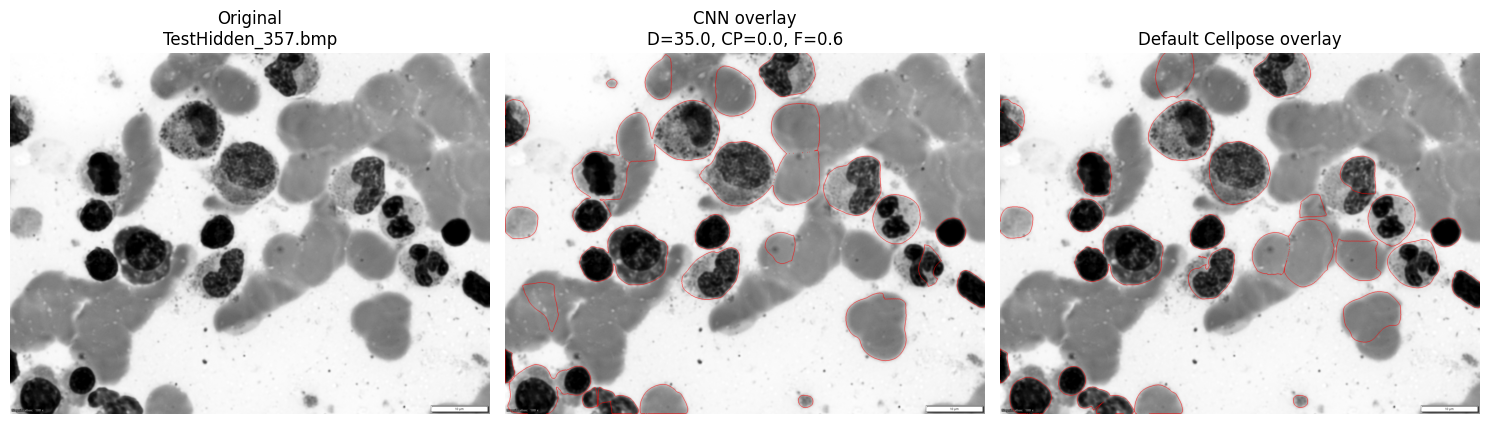

In [18]:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(normalize_image(img), cmap="gray")
    axes[0].set_title(f"Original\n{Path(img_path).name}")

    axes[1].imshow(pred_overlay)
    axes[1].set_title(
        f"CNN overlay\nD={combo['diameter']}, CP={combo['cellprob_threshold']}, F={combo['flow_threshold']}"
    )

    axes[2].imshow(default_overlay)
    axes[2].set_title("Default Cellpose overlay")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    save_path = OVERLAY_DIR / f"{Path(img_path).stem}_overlay_compare.png"
    plt.savefig(save_path, dpi=180, bbox_inches="tight")
    plt.show()

In [4]:
PROJECT_ROOT = Path(r"C:\Users\wangy\Downloads\cnn")


In [7]:
EVAL_IMG_DIR = PROJECT_ROOT / "test2" / "images"
EVAL_GT_DIR  = PROJECT_ROOT / "test2" / "ground_truth"

EVAL_OUT_DIR = OUT_DIR / "eval_with_gt"
EVAL_MASK_PRED_DIR = EVAL_OUT_DIR / "predicted_masks"
EVAL_MASK_DEFAULT_DIR = EVAL_OUT_DIR / "default_masks"
EVAL_COMPARE_DIR = EVAL_OUT_DIR / "comparisons"

for d in [EVAL_OUT_DIR, EVAL_MASK_PRED_DIR, EVAL_MASK_DEFAULT_DIR, EVAL_COMPARE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("EVAL_IMG_DIR exists:", EVAL_IMG_DIR.exists())
print("EVAL_GT_DIR exists:", EVAL_GT_DIR.exists())

EVAL_IMG_DIR exists: True
EVAL_GT_DIR exists: True


In [8]:
def image_key_from_path(p):
    stem = Path(p).stem
    for suffix in ["_labels", "_label", "-labels", "-label", " labels", " label"]:
        if stem.endswith(suffix):
            stem = stem[: -len(suffix)]
            break
    return stem

def read_mask_any(path):
    path = Path(path)
    ext = path.suffix.lower()

    if ext in {".tif", ".tiff"}:
        arr = tiff.imread(str(path))
    else:
        arr = np.array(Image.open(path))

    arr = np.asarray(arr)

    if arr.ndim == 3:
        if arr.shape[-1] in (3, 4):
            arr = arr[..., 0]
        else:
            arr = arr[0]

    if np.issubdtype(arr.dtype, np.floating):
        arr = np.rint(arr)

    arr = arr.astype(np.int32)

    if arr.max() <= 1:
        arr = sk_label(arr > 0)

    return arr

def resize_mask_to_shape(mask, shape_hw):
    if mask.shape == shape_hw:
        return mask.astype(np.int32)

    mask2 = resize(
        mask.astype(np.float32),
        shape_hw,
        order=0,
        preserve_range=True,
        anti_aliasing=False,
    )
    mask2 = np.rint(mask2).astype(np.int32)

    if mask2.max() <= 1:
        mask2 = sk_label(mask2 > 0)

    return mask2

def binary_dice(gt, pred):
    gt_b = (gt > 0)
    pr_b = (pred > 0)
    inter = np.logical_and(gt_b, pr_b).sum()
    denom = gt_b.sum() + pr_b.sum()
    if denom == 0:
        return 1.0
    return 2.0 * inter / denom

def binary_iou(gt, pred):
    gt_b = (gt > 0)
    pr_b = (pred > 0)
    inter = np.logical_and(gt_b, pr_b).sum()
    union = np.logical_or(gt_b, pr_b).sum()
    if union == 0:
        return 1.0
    return inter / union

In [9]:
EVAL_IMG_DIR = PROJECT_ROOT / "test2" / "images"
EVAL_GT_DIR  = PROJECT_ROOT / "test2" / "ground_truth"

EVAL_OUT_DIR = OUT_DIR / "eval_with_gt"
EVAL_MASK_PRED_DIR = EVAL_OUT_DIR / "predicted_masks"
EVAL_MASK_DEFAULT_DIR = EVAL_OUT_DIR / "default_masks"
EVAL_COMPARE_DIR = EVAL_OUT_DIR / "comparisons"

for d in [EVAL_OUT_DIR, EVAL_MASK_PRED_DIR, EVAL_MASK_DEFAULT_DIR, EVAL_COMPARE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("EVAL_IMG_DIR exists:", EVAL_IMG_DIR.exists())
print("EVAL_GT_DIR exists:", EVAL_GT_DIR.exists())

EVAL_IMG_DIR exists: True
EVAL_GT_DIR exists: True


In [10]:
def image_key_from_path(p):
    stem = Path(p).stem
    for suffix in ["_labels", "_label", "-labels", "-label", " labels", " label"]:
        if stem.endswith(suffix):
            stem = stem[: -len(suffix)]
            break
    return stem

def read_mask_any(path):
    path = Path(path)
    ext = path.suffix.lower()

    if ext in {".tif", ".tiff"}:
        arr = tiff.imread(str(path))
    else:
        arr = np.array(Image.open(path))

    arr = np.asarray(arr)

    if arr.ndim == 3:
        if arr.shape[-1] in (3, 4):
            arr = arr[..., 0]
        else:
            arr = arr[0]

    if np.issubdtype(arr.dtype, np.floating):
        arr = np.rint(arr)

    arr = arr.astype(np.int32)

    if arr.max() <= 1:
        arr = sk_label(arr > 0)

    return arr

def resize_mask_to_shape(mask, shape_hw):
    if mask.shape == shape_hw:
        return mask.astype(np.int32)

    mask2 = resize(
        mask.astype(np.float32),
        shape_hw,
        order=0,
        preserve_range=True,
        anti_aliasing=False,
    )
    mask2 = np.rint(mask2).astype(np.int32)

    if mask2.max() <= 1:
        mask2 = sk_label(mask2 > 0)

    return mask2

def binary_dice(gt, pred):
    gt_b = (gt > 0)
    pr_b = (pred > 0)
    inter = np.logical_and(gt_b, pr_b).sum()
    denom = gt_b.sum() + pr_b.sum()
    if denom == 0:
        return 1.0
    return 2.0 * inter / denom

def binary_iou(gt, pred):
    gt_b = (gt > 0)
    pr_b = (pred > 0)
    inter = np.logical_and(gt_b, pr_b).sum()
    union = np.logical_or(gt_b, pr_b).sum()
    if union == 0:
        return 1.0
    return inter / union

In [13]:
eval_images = list_images(EVAL_IMG_DIR)
eval_gts = list_images(EVAL_GT_DIR)

eval_img_map = {image_key_from_path(p): p for p in eval_images}
eval_gt_map  = {image_key_from_path(p): p for p in eval_gts}

eval_common_keys = sorted(set(eval_img_map) & set(eval_gt_map))
eval_missing_img = sorted(set(eval_gt_map) - set(eval_img_map))
eval_missing_gt  = sorted(set(eval_img_map) - set(eval_gt_map))

print("matched eval pairs:", len(eval_common_keys))
print("missing eval images for GT:", len(eval_missing_img))
print("missing eval GT for images:", len(eval_missing_gt))

eval_pairs = pd.DataFrame({
    "key": eval_common_keys,
    "img_path": [str(eval_img_map[k]) for k in eval_common_keys],
    "gt_path": [str(eval_gt_map[k]) for k in eval_common_keys],
})

display(eval_pairs.head())

matched eval pairs: 6
missing eval images for GT: 0
missing eval GT for images: 0


,key,img_path,gt_path
0,335,C:\Users\wangy\Downloads\cnn\test2\images\335.png,C:\Users\wangy\Downloads\cnn\test2\ground_trut...
1,337,C:\Users\wangy\Downloads\cnn\test2\images\337.png,C:\Users\wangy\Downloads\cnn\test2\ground_trut...
2,339,C:\Users\wangy\Downloads\cnn\test2\images\339.png,C:\Users\wangy\Downloads\cnn\test2\ground_trut...
3,347,C:\Users\wangy\Downloads\cnn\test2\images\347.png,C:\Users\wangy\Downloads\cnn\test2\ground_trut...
4,366,C:\Users\wangy\Downloads\cnn\test2\images\366.png,C:\Users\wangy\Downloads\cnn\test2\ground_trut...


In [20]:
eval_rows = []

for i, row in eval_pairs.iterrows():
    key = row["key"]
    img_path = Path(row["img_path"])
    gt_path = Path(row["gt_path"])

    print(f"[{i+1}/{len(eval_pairs)}] {img_path.name}")

    img = read_image_any(img_path)
    gt = read_mask_any(gt_path)
    gt = resize_mask_to_shape(gt, img.shape)

    pred_class, combo = predict_combo(model, combo_table, img_path, IMG_SIZE, DEVICE)

    pred_out = cp_model.eval(
        img,
        channels=CHANNELS,
        diameter=float(combo["diameter"]),
        cellprob_threshold=float(combo["cellprob_threshold"]),
        flow_threshold=float(combo["flow_threshold"]),
    )
    pred_masks = np.asarray(pred_out[0])
    pred_masks = resize_mask_to_shape(pred_masks, img.shape)

    default_out = cp_model.eval(
        img,
        channels=CHANNELS,
    )
    default_masks = np.asarray(default_out[0])
    default_masks = resize_mask_to_shape(default_masks, img.shape)

    pred_dice = binary_dice(gt, pred_masks)
    pred_iou = binary_iou(gt, pred_masks)

    default_dice = binary_dice(gt, default_masks)
    default_iou = binary_iou(gt, default_masks)

    pred_mask_path = EVAL_MASK_PRED_DIR / f"{key}_predicted_mask.tif"
    default_mask_path = EVAL_MASK_DEFAULT_DIR / f"{key}_default_mask.tif"

    tiff.imwrite(str(pred_mask_path), pred_masks.astype(np.int32))
    tiff.imwrite(str(default_mask_path), default_masks.astype(np.int32))

    gt_overlay = overlay_boundaries(img, gt)
    pred_overlay = overlay_boundaries(img, pred_masks)
    default_overlay = overlay_boundaries(img, default_masks)

    fig, axes = plt.subplots(1, 4, figsize=(18, 5))

    axes[0].imshow(normalize_image(img), cmap="gray")
    axes[0].set_title(f"Original\n{img_path.name}")

    axes[1].imshow(gt_overlay)
    axes[1].set_title("Ground Truth")

    axes[2].imshow(pred_overlay)
    axes[2].set_title(
        f"CNN overlay\nD={combo['diameter']}, CP={combo['cellprob_threshold']}, F={combo['flow_threshold']}\nDice={pred_dice:.3f}, IoU={pred_iou:.3f}"
    )

    axes[3].imshow(default_overlay)
    axes[3].set_title(
        f"Default overlay\nDice={default_dice:.3f}, IoU={default_iou:.3f}"
    )

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    compare_path = EVAL_COMPARE_DIR / f"{key}_comparison_with_gt.png"
    plt.savefig(compare_path, dpi=180, bbox_inches="tight")
    plt.close()

    eval_rows.append({
        "image_key": key,
        "image_name": img_path.name,
        "img_path": str(img_path),
        "gt_path": str(gt_path),
        "pred_combo_id": int(pred_class),
        "pred_diameter": float(combo["diameter"]),
        "pred_cellprob_threshold": float(combo["cellprob_threshold"]),
        "pred_flow_threshold": float(combo["flow_threshold"]),
        "cnn_dice": float(pred_dice),
        "cnn_iou": float(pred_iou),
        "default_dice": float(default_dice),
        "default_iou": float(default_iou),
        "dice_gain_cnn_minus_default": float(pred_dice - default_dice),
        "iou_gain_cnn_minus_default": float(pred_iou - default_iou),
        "pred_mask_path": str(pred_mask_path),
        "default_mask_path": str(default_mask_path),
        "comparison_figure_path": str(compare_path),
        "cnn_num_objects": int(pred_masks.max()) if pred_masks.size else 0,
        "default_num_objects": int(default_masks.max()) if default_masks.size else 0,
        "gt_num_objects": int(gt.max()) if gt.size else 0,
    })

[1/6] 335.png


channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
c:\Users\wangy\miniconda3\envs\cellpose\lib\site-packages\cellpose\dynamics.py:524: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:767.)
  coo = torch.sparse_coo_tensor(pt, torch.ones(pt.shape[1], device=pt.device, dtype=torch.int),
channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used


[2/6] 337.png


channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used


[3/6] 339.png


...

channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used


[5/6] 366.png


channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used


[6/6] 400.png


channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used
channels deprecated in v4.0.1+. If data contain more than 3 channels, only the first 3 channels will be used


In [21]:
eval_df = pd.DataFrame(eval_rows)

eval_summary_csv = EVAL_OUT_DIR / "eval_with_gt_summary.csv"
eval_df.to_csv(eval_summary_csv, index=False)

print("saved:", eval_summary_csv)
display(eval_df.head())

if len(eval_df) > 0:
    print("----- Aggregate metrics -----")
    print(f"CNN mean Dice:      {eval_df['cnn_dice'].mean():.4f}")
    print(f"Default mean Dice:  {eval_df['default_dice'].mean():.4f}")
    print(f"CNN mean IoU:       {eval_df['cnn_iou'].mean():.4f}")
    print(f"Default mean IoU:   {eval_df['default_iou'].mean():.4f}")
    print(f"Mean Dice gain:     {eval_df['dice_gain_cnn_minus_default'].mean():+.4f}")
    print(f"Mean IoU gain:      {eval_df['iou_gain_cnn_minus_default'].mean():+.4f}")
    print(
        f"CNN wins on Dice:   "
        f"{(eval_df['cnn_dice'] > eval_df['default_dice']).sum()} / {len(eval_df)}"
    )
    print(
        f"CNN wins on IoU:    "
        f"{(eval_df['cnn_iou'] > eval_df['default_iou']).sum()} / {len(eval_df)}"
    )

saved: C:\Users\wangy\Downloads\cnn\outputs\infer_compare\eval_with_gt\eval_with_gt_summary.csv


,image_key,image_name,img_path,gt_path,pred_combo_id,pred_diameter,pred_cellprob_threshold,pred_flow_threshold,cnn_dice,cnn_iou,default_dice,default_iou,dice_gain_cnn_minus_default,iou_gain_cnn_minus_default,pred_mask_path,default_mask_path,comparison_figure_path,cnn_num_objects,default_num_objects,gt_num_objects
0,335,335.png,C:\Users\wangy\Downloads\cnn\test2\images\335.png,C:\Users\wangy\Downloads\cnn\test2\ground_trut...,41,35.0,0.0,0.6,0.589164,0.417599,0.634490,0.464654,-0.045326,-0.047055,C:\Users\wangy\Downloads\cnn\outputs\infer_com...,C:\Users\wangy\Downloads\cnn\outputs\infer_com...,C:\Users\wangy\Downloads\cnn\outputs\infer_com...,36,27,255
1,337,337.png,C:\Users\wangy\Downloads\cnn\test2\images\337.png,C:\Users\wangy\Downloads\cnn\test2\ground_trut...,41,35.0,0.0,0.6,0.564802,0.393536,0.588867,0.417300,-0.024064,-0.023764,C:\Users\wangy\Downloads\cnn\outputs\infer_com...,C:\Users\wangy\Downloads\cnn\outputs\infer_com...,C:\Users\wangy\Downloads\cnn\outputs\infer_com...,25,16,255
2,339,339.png,C:\Users\wangy\Downloads\cnn\test2\images\339.png,C:\Users\wangy\Downloads\cnn\test2\ground_trut...,41,35.0,0.0,0.6,0.512594,0.344623,0.582461,0.410896,-0.069867,-0.066273,C:\Users\wangy\Downloads\cnn\outputs\infer_com...,C:\Users\wangy\Downloads\cnn\outputs\infer_com...,C:\Users\wangy\Downloads\cnn\outputs\infer_com...,12,12,255
3,347,347.png,C:\Users\wangy\Downloads\cnn\test2\images\347.png,C:\Users\wangy\Downloads\cnn\test2\ground_trut...,41,35.0,0.0,0.6,0.381950,0.236056,0.445543,0.286623,-0.063594,-0.050568,C:\Users\wangy\Downloads\cnn\outputs\infer_com...,C:\Users\wangy\Downloads\cnn\outputs\infer_com...,C:\Users\wangy\Downloads\cnn\outputs\infer_com...,30,21,255
4,366,366.png,C:\Users\wangy\Downloads\cnn\test2\images\366.png,C:\Users\wangy\Downloads\cnn\test2\ground_trut...,41,35.0,0.0,0.6,0.644378,0.475338,0.641606,0.472327,0.002772,0.003011,C:\Users\wangy\Downloads\cnn\outputs\infer_com...,C:\Users\wangy\Downloads\cnn\outputs\infer_com...,C:\Users\wangy\Downloads\cnn\outputs\infer_com...,92,81,255


----- Aggregate metrics -----
CNN mean Dice:      0.5440
Default mean Dice:  0.5962
CNN mean IoU:       0.3778
Default mean IoU:   0.4286
Mean Dice gain:     -0.0521
Mean IoU gain:      -0.0508
CNN wins on Dice:   1 / 6
CNN wins on IoU:    1 / 6


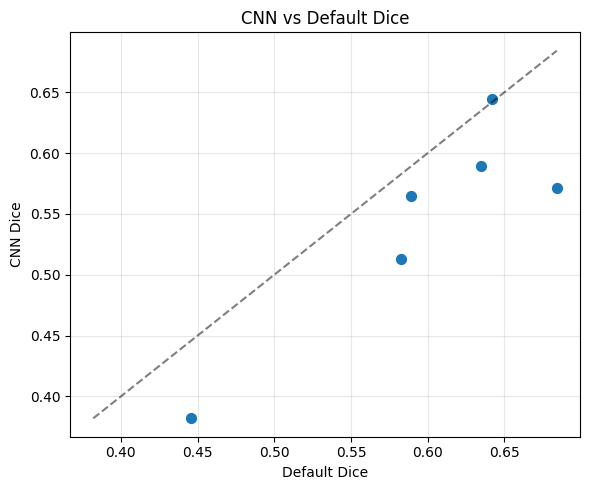

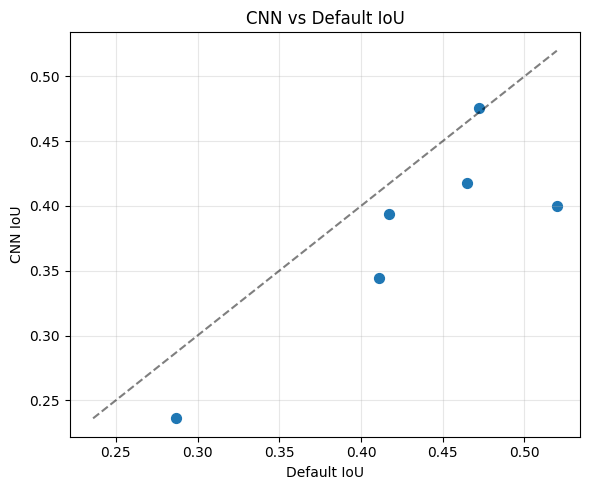

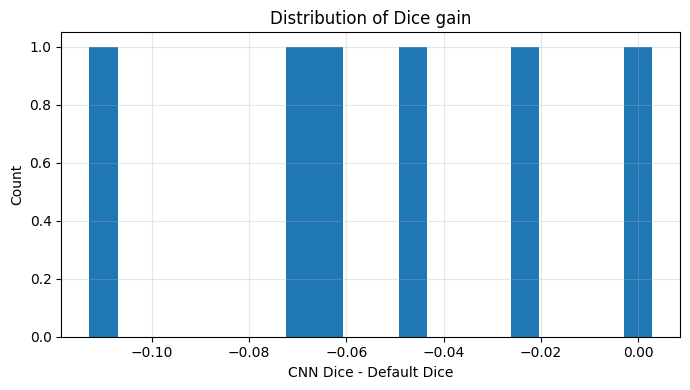

In [22]:
if len(eval_df) > 0:
    plt.figure(figsize=(6, 5))
    plt.scatter(eval_df["default_dice"], eval_df["cnn_dice"], s=50)
    lo = min(eval_df["default_dice"].min(), eval_df["cnn_dice"].min())
    hi = max(eval_df["default_dice"].max(), eval_df["cnn_dice"].max())
    plt.plot([lo, hi], [lo, hi], "k--", alpha=0.5)
    plt.xlabel("Default Dice")
    plt.ylabel("CNN Dice")
    plt.title("CNN vs Default Dice")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 5))
    plt.scatter(eval_df["default_iou"], eval_df["cnn_iou"], s=50)
    lo = min(eval_df["default_iou"].min(), eval_df["cnn_iou"].min())
    hi = max(eval_df["default_iou"].max(), eval_df["cnn_iou"].max())
    plt.plot([lo, hi], [lo, hi], "k--", alpha=0.5)
    plt.xlabel("Default IoU")
    plt.ylabel("CNN IoU")
    plt.title("CNN vs Default IoU")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.hist(eval_df["dice_gain_cnn_minus_default"], bins=20)
    plt.xlabel("CNN Dice - Default Dice")
    plt.ylabel("Count")
    plt.title("Distribution of Dice gain")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [26]:

for img_path in test_images:
    img = read_image_any(img_path)

    pred_class, combo = predict_combo(model, combo_table, img_path, IMG_SIZE, DEVICE)

    pred_out = cp_model.eval(
        img,
        channels=CHANNELS,
        diameter=float(combo["diameter"]),
        cellprob_threshold=float(combo["cellprob_threshold"]),
        flow_threshold=float(combo["flow_threshold"]),
    )
    pred_masks = np.asarray(pred_out[0])

    default_out = cp_model.eval(
        img,
        channels=CHANNELS,
    )
    default_masks = np.asarray(default_out[0])

    pred_overlay = make_mask_overlay(img, pred_masks, boundary_only=True)
    default_overlay = make_mask_overlay(img, default_masks, boundary_only=True)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(normalize_image(img), cmap="gray")
    axes[0].set_title(f"Original\n{Path(img_path).name}")

    axes[1].imshow(pred_overlay)
    axes[1].set_title(
        f"CNN overlay\nD={combo['diameter']}, CP={combo['cellprob_threshold']}, F={combo['flow_threshold']}"
    )

    axes[2].imshow(default_overlay)
    axes[2].set_title("Default Cellpose overlay")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

NameError: name 'test_images' is not defined